# ファクター検証　（reprisk）

`input/msci_india_imi/alpha/reprisk/repr_current_rri`（RepRisk Index, RRI）の検証

## 分位分析

### 目的

RRI の水準（レピュテーションリスク）が将来リターンと関係するかを、グループポートフォリオのリターン差で確認する。
`02_distribution` と `03_size` の所見から、通常の分位（順位で等分）はそのままでは使えない。

- 観測の半数がゼロで同順位のため、5 分位に切ると低リスク側の複数分位が同じ銘柄群になる
- RRI はサイズと相関 0.38 で、特に「非ゼロかどうか」が最大分位に集中している

そこで次の順で見る。

1. **参考**: 通常の 5 分位（`alphaeval.quantile_analysis`）で同順位問題を確認する
2. **3 群比較**: RRI 帯（ゼロ / 1–24 / 25 以上）ごとの等ウェイトポートフォリオ
3. **非ゼロ内の分位**: 非ゼロ銘柄だけを 3 分位に切り、ゼロ群と並べる
4. **サイズ制御**: ベンチマーク内に限定した 3 群、およびサイズ分位（S3〜S5）内で 3 群を作り分位間で等ウェイト合成した層化版

### 定義

- グループ $g$ の $t$ 時点の等ウェイト $w_{i,t} = I_{i,t}^{(g)} / \sum_j I_{j,t}^{(g)}$、リターン $r^{(g)}_{t+1} = \sum_i w_{i,t}\, r_{i,t+1}$
- リターンは `risk_models/GEMLT/return` の `rtn`（INR 建てトータルリターン、小数）
- 比較対象は 2 つ。ベンチマーク（MSCI India、時価総額ウェイト）と、**スコアあり銘柄の等ウェイト**（EW 参照）。
  グループは等ウェイトなので、サイズ効果を除いた「グループ選択の効果」は EW 参照との差で見る
- 回転率は片道（$\tfrac12\sum_i |w_{i,t} - w^-_{i,t}|$、ドリフト調整済み）
- 方向: RRI は**低いほど良い**（リスクが低い）と仮定する。「ゼロ − 25 以上」を低リスク側のスプレッドとする

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語ラベル用
import numpy as np
import pandas as pd

from alphaeval import (
    InputStore,
    performance_summary,
    portfolio_returns,
    quantile_analysis,
    turnover,
    weight_portfolio,
)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 30)

# ---- パラメータ
INPUT_ROOT = "../../input/msci_india_imi"
SCORE = "reprisk/repr_current_rri"
BENCHMARK = "msci_india"
RISK_MODEL, RETURN_COL = "GEMLT", "rtn"
START, END = 200801, 202606       # スコア・ウェイトの期間（リターンは 1 か月先まで読む）
N_SIZE_BINS = 5
BANDS = {"ゼロ": (-0.5, 0.5), "1–24": (0.5, 24.5), "25以上": (24.5, 1000)}

store = InputStore(INPUT_ROOT)

### 1. データ読み込み

In [2]:
univ = store.universe(START, END)
bm = store.benchmark(BENCHMARK, START, END)
score = store.alpha(SCORE, START, END)
rtn = store.returns(RISK_MODEL, RETURN_COL, START, 202607)

score_u = score.where(univ.notna())
log_size = np.log(univ.where(univ > 0))
size_bin = np.ceil(log_size.rank(axis=1, pct=True) * N_SIZE_BINS).clip(1, N_SIZE_BINS)
in_bm = bm.reindex(index=univ.index, columns=univ.columns).notna()

bm_ret = portfolio_returns(bm, rtn)                    # ベンチマーク（時価総額ウェイト）
ew_ref = weight_portfolio(score_u.notna())             # スコアあり銘柄の等ウェイト
ew_ret = portfolio_returns(ew_ref, rtn)
print(f"期間: {univ.index.min().date()} 〜 {univ.index.max().date()} ({len(univ)} か月)、リターン {rtn.shape}")

期間: 2008-01-31 〜 2026-06-30 (222 か月)、リターン (223, 1061)


分析用のヘルパー。グループの組入判定（bool パネル）から等ウェイトのリターン・回転率・銘柄数を計算し、
ベンチマークと EW 参照に対する指標をまとめる。

In [3]:
def run_groups(members: dict[str, pd.DataFrame], weights: dict[str, pd.DataFrame] | None = None):
    """グループごとの等ウェイトポートフォリオを評価する。weights を渡せばそれを使う。"""
    rets, tos, ns = {}, {}, {}
    for name, m in members.items():
        w = weights[name] if weights is not None else weight_portfolio(m)
        rets[name] = portfolio_returns(w, rtn)
        tos[name] = turnover(w, rtn)
        ns[name] = m.sum(axis=1)
    return pd.DataFrame(rets), pd.DataFrame(tos), pd.DataFrame(ns)


def summarize(rets: pd.DataFrame, tos: pd.DataFrame | None, ns: pd.DataFrame | None) -> pd.DataFrame:
    """基本指標 + ベンチマーク対比 + EW 参照対比をまとめた表。"""
    rows = {}
    for name in rets.columns:
        r = rets[name]
        base = performance_summary(r, bm_ret.reindex(r.index), tos[name] if tos is not None and name in tos else None)
        ref = performance_summary(r, ew_ret.reindex(r.index))
        rows[name] = pd.Series(
            {
                "年率リターン": base["ann_return"],
                "年率リスク": base["ann_volatility"],
                "R/R": base["return_risk"],
                "最大DD": base["max_drawdown"],
                "年率回転率": base.get("turnover_annual", np.nan),
                "平均銘柄数": ns[name].mean() if ns is not None and name in ns else np.nan,
                "超過(vs BM)": base["active_return"],
                "TE(vs BM)": base["tracking_error"],
                "IR(vs BM)": base["information_ratio"],
                "超過(vs EW)": ref["active_return"],
                "TE(vs EW)": ref["tracking_error"],
                "IR(vs EW)": ref["information_ratio"],
                "勝率(vs EW)": ref["active_hit_rate"],
            }
        )
    return pd.DataFrame(rows)


def plot_relative(rets: pd.DataFrame, ref: pd.Series, title: str) -> None:
    """参照ポートフォリオに対する累積相対リターンを描く。"""
    rel = (1 + rets).cumprod().div((1 + ref.reindex(rets.index)).cumprod(), axis=0)
    ax = rel.plot(figsize=(11, 4), logy=True)
    ax.axhline(1, color="k", linewidth=0.8)
    ax.set_ylabel("累積相対リターン（対数）")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def yearly_table(rets: pd.DataFrame, ref: pd.Series) -> pd.DataFrame:
    """年ごとの累積リターン（EW 参照との差）。"""
    ex = rets.sub(ref.reindex(rets.index), axis=0)
    return ex.groupby(ex.index.year).apply(lambda x: (1 + x).prod() - 1).round(3)


def band_members(s: pd.DataFrame) -> dict[str, pd.DataFrame]:
    return {name: (s >= lo) & (s < hi) for name, (lo, hi) in BANDS.items()}

### 2. 参考: 通常の 5 分位

`quantile_analysis(higher_is_better=False)` で RRI が低いほど上位（Q1）になるよう 5 分位に切る。
同順位（ゼロ）が平均順位を取るため、ゼロ銘柄は全員同じパーセンタイルになり、分位境界がゼロ帯の内側に落ちると
ゼロ銘柄全員が 1 つの分位に入る（他の分位は空になる）か、境界の位置によって分かれ方が変わる。

In [4]:
q5 = quantile_analysis(score_u, rtn, univ, n_quantiles=5, higher_is_better=False)
print("平均銘柄数（分位ごと）")
display(q5.n_holdings.mean().round(1).to_frame("平均銘柄数").T)
display(summarize(q5.returns[q5.labels], q5.turnover, q5.n_holdings).round(3))

平均銘柄数（分位ごと）


,Q1,Q2,Q3,Q4,Q5
平均銘柄数,10.3,130.7,23.6,44.4,52.3


,Q1,Q2,Q3,Q4,Q5
年率リターン,0.010,0.136,0.097,0.134,0.106
年率リスク,0.061,0.276,0.206,0.259,0.269
R/R,0.167,0.493,0.470,0.517,0.393
最大DD,-0.205,-0.600,-0.505,-0.497,-0.559
年率回転率,0.091,1.178,2.565,3.003,2.319
平均銘柄数,10.297,130.739,23.644,44.392,52.306
超過(vs BM),-0.100,0.054,0.002,0.047,0.024
TE(vs BM),0.202,0.134,0.198,0.131,0.113
IR(vs BM),-0.495,0.405,0.010,0.359,0.217
超過(vs EW),-0.136,0.018,-0.034,0.011,-0.012


### 3. 3 群比較（ゼロ / 1–24 / 25 以上）

RRI 帯ごとの等ウェイトポートフォリオ。加えて「ゼロ − 25 以上」（低リスク − 高リスク）のスプレッドを見る。

,ゼロ,1–24,25以上,ゼロ−25以上,1–24−25以上
年率リターン,0.124,0.126,0.060,0.053,0.051
年率リスク,0.279,0.263,0.280,0.113,0.103
R/R,0.445,0.478,0.213,0.469,0.498
最大DD,-0.625,-0.510,-0.674,-0.247,-0.216
年率回転率,0.868,1.666,6.402,NaN,NaN
平均銘柄数,140.131,101.207,20.041,NaN,NaN
超過(vs BM),0.044,0.041,-0.014,-0.054,-0.057
TE(vs BM),0.130,0.109,0.139,0.228,0.230
IR(vs BM),0.339,0.379,-0.099,-0.237,-0.247
超過(vs EW),0.008,0.005,-0.050,-0.090,-0.093


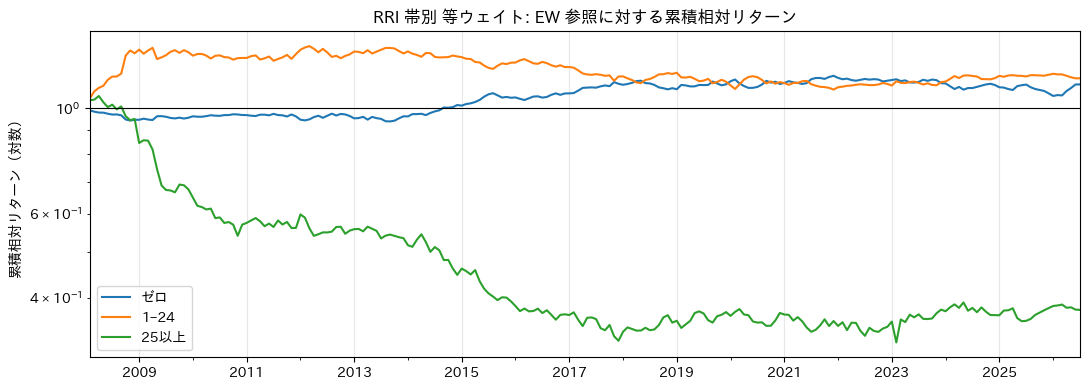

In [5]:
members3 = band_members(score_u)
rets3, tos3, ns3 = run_groups(members3)
rets3["ゼロ−25以上"] = rets3["ゼロ"] - rets3["25以上"]
rets3["1–24−25以上"] = rets3["1–24"] - rets3["25以上"]
display(summarize(rets3, tos3, ns3).round(3))
plot_relative(rets3[list(BANDS)], ew_ret, "RRI 帯別 等ウェイト: EW 参照に対する累積相対リターン")

In [6]:
print("年別: EW 参照に対する超過リターン")
display(yearly_table(rets3[list(BANDS)], ew_ret))

年別: EW 参照に対する超過リターン


,ゼロ,1–24,25以上
2008,-0.045,0.249,-0.027
2009,0.016,-0.014,-0.328
2010,0.013,-0.027,-0.155
2011,-0.006,0.017,-0.016
2012,-0.005,0.008,0.000
2013,-0.000,0.003,-0.032
2014,0.056,-0.013,-0.167
2015,0.035,-0.029,-0.120
2016,0.022,-0.022,-0.058
2017,0.049,-0.045,-0.123


### 4. 非ゼロ銘柄内の分位 + ゼロ群

非ゼロ銘柄だけを対象に RRI で 3 分位（T1 = 低、T3 = 高）に切り、ゼロ群と並べる。
帯（水準）ではなく順位で切るので、スコア水準の上昇トレンド（`02_distribution`）の影響を受けない。

,ゼロ,非ゼロT1(低),非ゼロT2,非ゼロT3(高),T1−T3,ゼロ−T3
年率リターン,0.124,0.127,0.113,0.104,0.011,0.014
年率リスク,0.279,0.264,0.266,0.283,0.106,0.092
R/R,0.445,0.483,0.425,0.368,0.107,0.149
最大DD,-0.625,-0.545,-0.525,-0.579,-0.370,-0.278
年率回転率,0.868,2.254,3.601,3.138,NaN,NaN
平均銘柄数,140.131,40.288,40.275,40.685,NaN,NaN
超過(vs BM),0.044,0.043,0.031,0.026,-0.095,-0.094
TE(vs BM),0.130,0.128,0.115,0.128,0.250,0.228
IR(vs BM),0.339,0.338,0.272,0.204,-0.380,-0.412
超過(vs EW),0.008,0.007,-0.005,-0.010,-0.131,-0.130


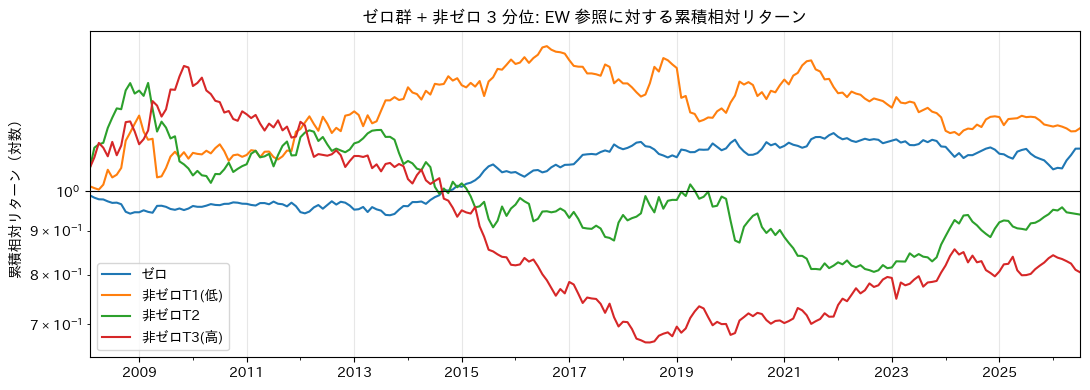

In [7]:
nonzero = score_u.where(score_u > 0)
qn = quantile_analysis(nonzero, rtn, univ, n_quantiles=3, higher_is_better=False)
members_nz = {"ゼロ": members3["ゼロ"]}
for q, label in zip(range(1, 4), ["非ゼロT1(低)", "非ゼロT2", "非ゼロT3(高)"]):
    members_nz[label] = qn.weights[q].notna() & (qn.weights[q] > 0)
rets_nz, tos_nz, ns_nz = run_groups(members_nz)
rets_nz["T1−T3"] = rets_nz["非ゼロT1(低)"] - rets_nz["非ゼロT3(高)"]
rets_nz["ゼロ−T3"] = rets_nz["ゼロ"] - rets_nz["非ゼロT3(高)"]
display(summarize(rets_nz, tos_nz, ns_nz).round(3))
plot_relative(rets_nz[list(members_nz)], ew_ret, "ゼロ群 + 非ゼロ 3 分位: EW 参照に対する累積相対リターン")

### 5. サイズ制御

#### 5a. ベンチマーク内（大型・中型）に限定した 3 群

ベンチマーク構成銘柄だけで RRI 帯のポートフォリオを作る。参照もベンチマーク内のスコアあり銘柄の等ウェイトに変える。

,ゼロ,1–24,25以上,ゼロ−25以上
年率リターン,0.112,0.118,0.058,0.032
年率リスク,0.237,0.229,0.268,0.146
R/R,0.473,0.513,0.217,0.219
最大DD,-0.585,-0.476,-0.684,-0.517
年率回転率,1.074,1.912,5.840,NaN
平均銘柄数,22.815,46.986,13.811,NaN
超過(vs BM),0.023,0.026,-0.019,-0.070
TE(vs BM),0.080,0.067,0.134,0.258
IR(vs BM),0.287,0.380,-0.141,-0.271
超過(vs EW),0.008,0.011,-0.034,-0.085


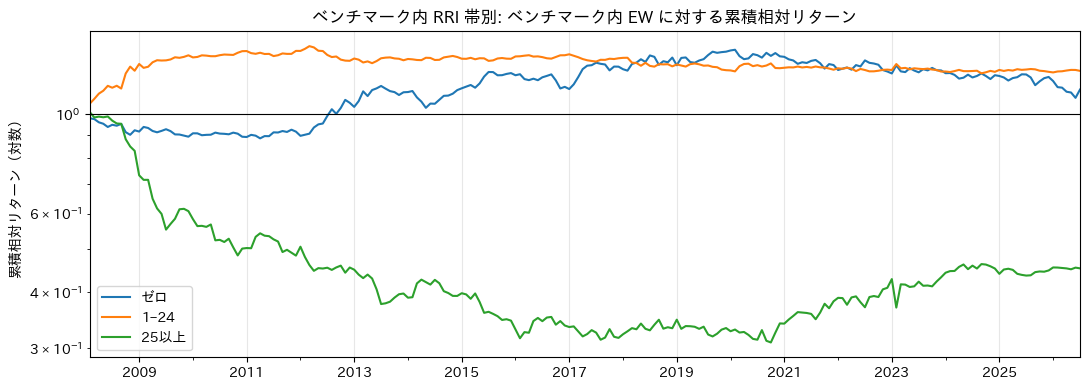

In [8]:
score_bm = score_u.where(in_bm)
members_bm = band_members(score_bm)
rets_bm, tos_bm, ns_bm = run_groups(members_bm)
ew_bm_ret = portfolio_returns(weight_portfolio(score_bm.notna()), rtn)
rets_bm["ゼロ−25以上"] = rets_bm["ゼロ"] - rets_bm["25以上"]

ew_ret_backup = ew_ret
ew_ret = ew_bm_ret  # summarize の EW 参照をベンチマーク内 EW に差し替え
display(summarize(rets_bm, tos_bm, ns_bm).round(3))
plot_relative(rets_bm[list(BANDS)], ew_bm_ret, "ベンチマーク内 RRI 帯別: ベンチマーク内 EW に対する累積相対リターン")
ew_ret = ew_ret_backup

#### 5b. サイズ層化（S3〜S5）

サイズ 5 分位のうち S3〜S5 で、各分位の内側で RRI 帯ポートフォリオ（等ウェイト）を作り、分位間は等ウェイトで合成する。
帯ごとの平均サイズを揃えるので、帯間のリターン差からサイズ効果が除かれる。
参照は同じ構成（S3〜S5 の各分位内 EW を等ウェイト合成）。

,ゼロ,1–24,25以上,ゼロ−25以上
年率リターン,0.124,0.111,0.016,0.067
年率リスク,0.256,0.270,0.320,0.185
R/R,0.487,0.410,0.050,0.363
最大DD,-0.605,-0.537,-0.720,-0.324
年率回転率,1.332,2.290,7.427,NaN
平均銘柄数,83.032,77.311,17.468,NaN
超過(vs BM),0.039,0.029,-0.044,-0.029
TE(vs BM),0.102,0.120,0.201,0.286
IR(vs BM),0.378,0.242,-0.219,-0.102
超過(vs EW),0.008,-0.002,-0.075,-0.060


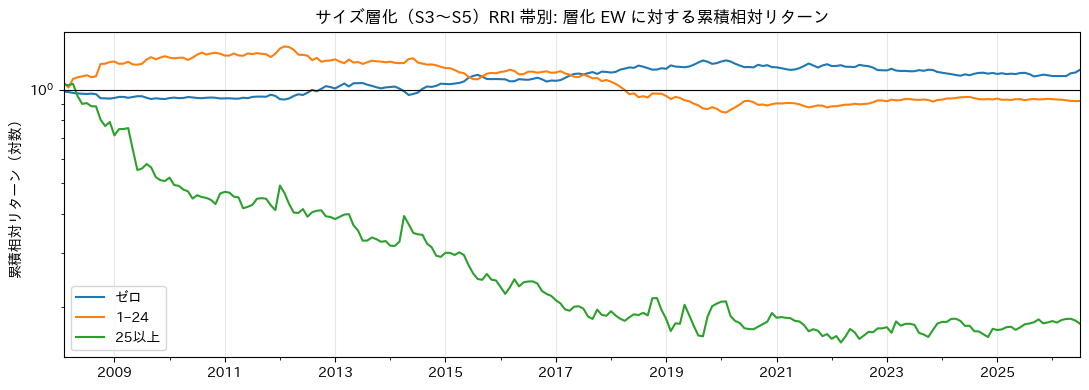

In [9]:
SIZE_BINS_USED = [3, 4, 5]

def stratified_weights(member: pd.DataFrame) -> pd.DataFrame:
    """サイズ分位ごとに等ウェイトを作り、分位間を等ウェイトで合成する（空の分位は除く）。"""
    parts = []
    for k in SIZE_BINS_USED:
        w = weight_portfolio(member & (size_bin == k))
        parts.append(w.fillna(0.0))
    total = sum(parts)
    rowsum = total.sum(axis=1)
    return total.div(rowsum.where(rowsum > 0), axis=0)

members_st = band_members(score_u)
weights_st = {name: stratified_weights(m & size_bin.isin(SIZE_BINS_USED)) for name, m in members_st.items()}
members_st = {name: m & size_bin.isin(SIZE_BINS_USED) for name, m in members_st.items()}
rets_st, tos_st, ns_st = run_groups(members_st, weights_st)
ew_st_ret = portfolio_returns(stratified_weights(score_u.notna() & size_bin.isin(SIZE_BINS_USED)), rtn)
rets_st["ゼロ−25以上"] = rets_st["ゼロ"] - rets_st["25以上"]

ew_ret_backup = ew_ret
ew_ret = ew_st_ret
display(summarize(rets_st, tos_st, ns_st).round(3))
plot_relative(rets_st[list(BANDS)], ew_st_ret, "サイズ層化（S3〜S5）RRI 帯別: 層化 EW に対する累積相対リターン")
ew_ret = ew_ret_backup

#### 5c. サイズ分位ごとの内訳

層化版の中身として、サイズ分位ごとに「ゼロ − 25 以上」と「ゼロ − 非ゼロ」のスプレッドを見る。
S1・S2 は 25 以上がほとんど無いため「ゼロ − 非ゼロ」のみ。

In [10]:
rows = {}
for k in range(1, N_SIZE_BINS + 1):
    m_bin = size_bin == k
    mem = {"ゼロ": members3["ゼロ"] & m_bin, "非ゼロ": (score_u > 0) & m_bin, "25以上": members3["25以上"] & m_bin}
    r, _, n = run_groups(mem)
    z_nz = r["ゼロ"] - r["非ゼロ"]
    z_hi = r["ゼロ"] - r["25以上"]
    rows[f"S{k}"] = {
        "ゼロ 銘柄数": n["ゼロ"].mean(),
        "非ゼロ 銘柄数": n["非ゼロ"].mean(),
        "25以上 銘柄数": n["25以上"].mean(),
        "ゼロ−非ゼロ 年率": z_nz.mean() * 12,
        "ゼロ−非ゼロ IR": z_nz.mean() / z_nz.std() * np.sqrt(12),
        "ゼロ−25以上 年率": z_hi.mean() * 12,
        "ゼロ−25以上 IR": z_hi.mean() / z_hi.std() * np.sqrt(12),
    }
display(pd.DataFrame(rows).T.round(3))

,ゼロ 銘柄数,非ゼロ 銘柄数,25以上 銘柄数,ゼロ−非ゼロ 年率,ゼロ−非ゼロ IR,ゼロ−25以上 年率,ゼロ−25以上 IR
S1,26.878,11.950,1.338,-0.038,-0.206,0.061,0.150
S2,30.221,14.518,1.234,-0.042,-0.274,-0.023,-0.073
S3,32.495,16.464,1.707,0.025,0.168,0.122,0.327
S4,31.383,26.820,3.739,0.026,0.222,0.083,0.282
S5,19.153,51.495,12.023,-0.005,-0.055,0.045,0.291


### 6. 所見

**参考: 通常の 5 分位（同順位問題の確認）**

- ゼロ銘柄（半数）が同じ平均順位を取るため、月によっては全員が Q2 に入り（平均 131 銘柄）、Q1 は
  ゼロ比率が 40% を下回る月にだけ銘柄が入る（平均 10 銘柄、空の月が多い）。Q1 の年率 1.0%・リスク 6.1% は
  空の月の 0 リターンによるもので、意味のある数字ではない。**RRI に順位ベースの等分分位は使えない。**

**3 群比較（ゼロ / 1–24 / 25 以上、等ウェイト）**

| | ゼロ | 1–24 | 25 以上 |
| --- | --- | --- | --- |
| 年率リターン | 12.4% | 12.6% | 6.0% |
| 超過（vs EW 参照） | +0.8% | +0.5% | −5.0% |
| IR（vs EW 参照） | 0.28 | 0.12 | −0.51 |
| 平均銘柄数 | 140 | 101 | 20 |
| 年率回転率 | 87% | 167% | 640% |

- ゼロと 1–24 の差はほぼ無く、**情報は「25 以上」の劣後に集中**している。「ゼロ − 25 以上」は年率 5.3%、R/R 0.47。
- 年別に見ると 25 以上の劣後は 2009〜2017 年に集中（2009 年 −33%、2014 年 −17%、2015 年 −12%、2017 年 −12%）。
  2018 年以降はほぼ横ばい（2018 年 +8.5%、2023 年 +9.4% と勝つ年もある）。累積相対リターンの図でも 2017 年以降は平坦。
- 25 以上は 20 銘柄と少なく、回転率 640% は RRI が 25 前後を頻繁に行き来することを示す。
  閾値をまたぐ売買を抑えるには `docs/india_tcg.md` §3 のバッファ（例: 25 で除外、20 で復帰）が要る。

**非ゼロ内の 3 分位**

- T1（低）12.7%、T2 11.3%、T3（高）10.4% と順序は正しいが、T1 − T3 は年率 1.1%、R/R 0.11 と弱い。
  非ゼロの中の順位にはほとんど情報が無く、やはり 25 以上のテール（T3 の一部）だけが効いている。

**サイズ制御**

- ベンチマーク内に限定: ゼロ − 25 以上は年率 3.2%（R/R 0.22）。25 以上（14 銘柄）はベンチマーク内 EW に対して
  −3.4%（IR −0.31）。大型・中型の中でも符号は保たれるが、効果は小さくなる。
- サイズ層化（S3〜S5 の各分位内で構築し等ウェイト合成）: 25 以上は年率 1.6%、層化 EW に対して −7.5%（IR −0.45）。
  ゼロ − 25 以上は年率 6.7%、R/R 0.36。**サイズを揃えると 25 以上の劣後はむしろ強まる**。
  RRI 高 = 大型 で大型株が相対的に堅調だった分、生の比較ではサイズ効果が劣後を隠していた。
- サイズ分位別: ゼロ − 25 以上は S1・S3・S4・S5 で正（S2 のみ負）。一方「ゼロ − 非ゼロ」は S1・S2・S5 で負、
  S3・S4 で正と一貫しない。「非ゼロかどうか」には情報が無く、「25 以上かどうか」に情報がある。

**まとめと後続ステップ**

1. RRI はアルファ（順位で並べる指標）ではなく、**高リスク・テールの除外スクリーン**として扱うのが自然。
   有効な情報は「RRI ≥ 25（RepRisk の「中」以上）の銘柄が EW 対比で年率 5〜7% 劣後する」の一点で、
   サイズを制御しても残る。
2. ただし劣後は 2009〜2017 年に集中し、2018 年以降は観測されない。RepRisk のカバレッジ拡張（`02_distribution`）で
   25 以上の銘柄数が 2008 年の 9 から 2026 年の 60 へ増え、閾値の意味が変わっている可能性がある。
   **閾値の感応度（20 / 25 / 30、あるいはクロスセクションの上位 x%）と期間別の安定性**を次に確認する。
3. 除外スクリーンとして使う場合の運用上の論点は回転率。25 以上への出入りが激しいため、
   バッファ付きの除外ルールで回転率と効果のトレードオフを見る。
4. IC は「テールだけに情報がある」性質から小さく出ると予想される。IC のステップでは Spearman に加えて
   「25 以上ダミー」と将来リターンの相関、およびサイズ中立化後の値を並べる。